# Time Series Analysis

## RAS and Player Position By Draft Year

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import widgets, interact

import sys
sys.path.append('../src')
from helpers import column_utils, csv_utils, merge_utils

In [27]:
df = csv_utils.csv_read('../data/cleaned/merged_ras_base_right_join_copy.csv', ',')

In [28]:
df.head(3)

,year,name,college,pos,height,weight,hand_size,arm_length,wonderlic,40_yard,...,Link,Name,POS,College,Year,RAS,Alltime RAS,Round,Draft Team,key_y
0,2003.0,justinfargas,Southern California,RB,72.90,219.0,9.75,31.00,NaN,4.41,...,"<a class=""nt_btn "" style=""color: rgba(0, 0, 0,...",justinfargas,RB,Southern California,2003,10.0,10.0,3,raiders,justinfargas_2003
1,2009.0,davidbuehler,Southern California,K,73.75,227.0,NaN,NaN,NaN,4.63,...,"<a class=""nt_btn "" style=""color: rgba(0, 0, 0,...",davidbuehler,PK,Southern California,2009,10.0,10.0,5,cowboys,davidbuehler_2009
2,2023.0,anthonyrichardson,Florida,QB,76.25,244.0,10.50,32.75,NaN,4.43,...,"<a class=""nt_btn "" style=""color: rgba(0, 0, 0,...",anthonyrichardson,QB,Florida,2023,10.0,10.0,1,colts,anthonyrichardson_2023


In [29]:
df['POS'].unique()

<StringArray>
['RB', 'PK', 'QB', 'LB', 'TE', 'OG', 'OT', 'CB', 'DT', 'OC', 'DE', 'SS', 'WR',
 'FS', 'FB', 'LS', 'DB']
Length: 17, dtype: str

In [30]:
df_ras_position = df.groupby(['Year', 'POS'])['RAS'].median().reset_index()
df_ras_round = df.groupby(['Year', 'Round'])['RAS'].median().reset_index()

In [31]:
df_ras_position

,Year,POS,RAS
0,1987,CB,6.840
1,1987,DE,5.715
2,1987,DT,5.710
3,1987,FB,6.000
4,1987,FS,6.875
...,...,...,...
618,2026,QB,7.820
619,2026,RB,8.735
620,2026,SS,9.285
621,2026,TE,9.270


In [32]:
df_ras_round

,Year,Round,RAS
0,1987,1,8.270
1,1987,2,6.900
2,1987,3,5.000
3,1987,4,5.810
4,1987,5,6.320
...,...,...,...
275,2026,3,9.090
276,2026,4,9.050
277,2026,5,8.675
278,2026,6,7.890


In [48]:
years = df['Year'].unique()
years.sort()
print(years)

[1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000
 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014
 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026]


In [54]:
def plot_lines(df, filter_col, selection):
    if len(selection) == 0:
        display("Select at least one value")
        return

    df_ras_filter_col = df[df[filter_col].isin(selection)].groupby(['Year', filter_col])['RAS'].median().reset_index()
    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(data=df_ras_filter_col, x='Year', y='RAS', hue=filter_col)
    plt.title(f"Median RAS by {filter_col}")
    plt.xlabel("Year")
    plt.ylabel("Median RAS")
    plt.xticks(rotation=45, ticks=years)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [50]:
def interactive_lineplot(df, filter_col):
    options = df[filter_col].dropna().unique()

    @interact(selected_values=widgets.SelectMultiple(options=options, value=[options[0]]))
    def plot(selected_values):
        plot_lines(df, filter_col, selected_values)

<Axes: xlabel='Year', ylabel='RAS'>

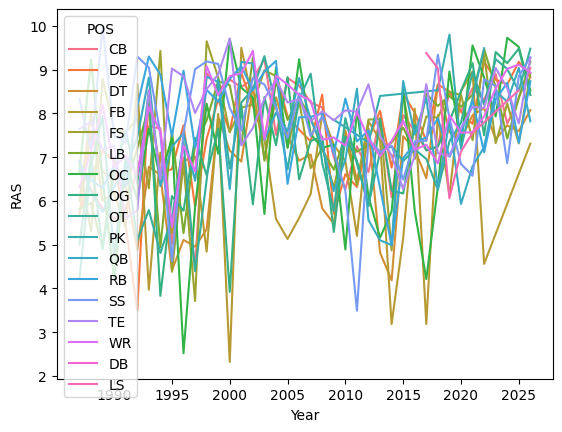

In [39]:
sns.lineplot(data=df_ras_position, x='Year', y='RAS', hue='POS')
# plot_lines(df, 'POS', ['CB'])

<Axes: xlabel='Year', ylabel='RAS'>

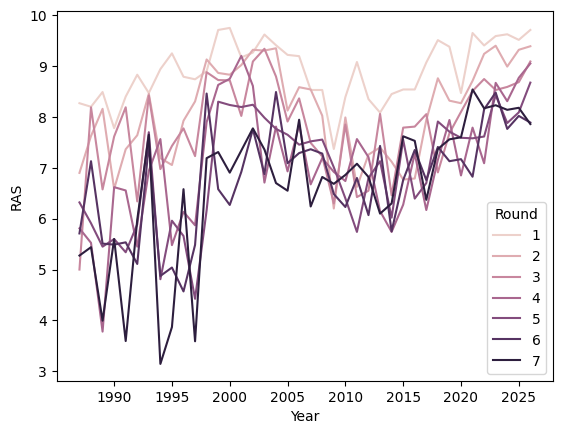

In [36]:
sns.lineplot(data=df_ras_round, x='Year', y='RAS', hue='Round')

In [55]:

interactive_lineplot(df, filter_col="POS")


interactive(children=(SelectMultiple(description='selected_values', index=(0,), options=('RB', 'PK', 'QB', 'LB…

In [ ]:
interactive_lineplot(df, filter_col="Round")

interactive(children=(SelectMultiple(description='selected_values', index=(0,), options=(np.int64(3), np.int64…